# Final Test-Set Evaluation

This notebook evaluates the best model (selected from the optimization phase) on the test set that was set aside at the beginning.

## Important Notes

1. **Test Set Used**: The test set used here is the SAME one that was reserved at the start of the project and NOT used during model optimization
2. **Best Model**: The best model identified in the optimization phase is retrained on the ENTIRE training set
3. **Final Evaluation**: Multiple metrics are reported (Accuracy, Precision, Recall, F1-Score, ROC-AUC)
4. **Visualization**: Confusion matrices and ROC curves are provided for detailed performance analysis

## Notebook Structure
- Load best model and preprocessor
- Load test set
- Make predictions on test set
- Calculate and report comprehensive metrics
- Generate visualizations

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import torch
import torch.nn as nn

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Test Set

In [2]:
# Load the test set that was reserved during the initial train-test split
X_test = pd.read_csv('../Data/X_test_for_evaluation.csv')
y_test = pd.read_csv('../Data/y_test_for_evaluation.csv').squeeze()

print(f"Test set loaded successfully!")
print(f"Test set shape: {X_test.shape}")
print(f"Test set target distribution:")
print(y_test.value_counts())
print(f"\nTest set class proportions:")
print(y_test.value_counts(normalize=True))

Test set loaded successfully!
Test set shape: (8238, 20)
Test set target distribution:
y
0    7310
1     928
Name: count, dtype: int64

Test set class proportions:
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


## 3. Load Best Model and Preprocessor

In [3]:
# Load best models info
with open('../OUTPUT/best_models.pkl', 'rb') as f:
    best_models_info = pickle.load(f)

# Load preprocessor
with open('../OUTPUT/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

print("Best models info and preprocessor loaded successfully!")

# Display all models' cross-validation performance
print("\n" + "="*70)
print("CROSS-VALIDATION PERFORMANCE (From Optimization Phase)")
print("="*70)

for model_name, info in best_models_info.items():
    print(f"\n{model_name.upper()}")
    print(f"  Best Parameters: {info['params']}")
    print(f"  Cross-Val ROC-AUC: {info['cv_score']:.4f}")
    print(f"  Cross-Val Metrics:")
    for metric, value in info['cv_metrics'].items():
        if isinstance(value, (int, float)):
            print(f"    - {metric}: {value:.4f}")

Best models info and preprocessor loaded successfully!

CROSS-VALIDATION PERFORMANCE (From Optimization Phase)

LOGISTIC_REGRESSION
  Best Parameters: {'classifier__C': 1, 'classifier__penalty': 'l1'}
  Cross-Val ROC-AUC: 0.9337
  Cross-Val Metrics:
    - accuracy: 0.9104
    - precision: 0.6614
    - recall: 0.4218
    - f1: 0.5149
    - roc_auc: 0.9337

SVM
  Best Parameters: {'kernel': 'linear', 'C': 1}
  Cross-Val ROC-AUC: 0.9310
  Cross-Val Metrics:
    - accuracy: 0.9042
    - precision: 0.6511
    - recall: 0.3233
    - f1: 0.4316
    - roc_auc: 0.9310

GRADIENT_BOOSTING
  Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 150}
  Cross-Val ROC-AUC: 0.9470
  Cross-Val Metrics:
    - accuracy: 0.9149
    - precision: 0.6471
    - recall: 0.5385
    - f1: 0.5877
    - roc_auc: 0.9470

NEURAL_NETWORK
  Best Parameters: {'hidden_dim1': 64, 'hidden_dim2': 32,

## 4. Identify Best Model

In [4]:
# Find the best model based on ROC-AUC
best_model_name = max(best_models_info.keys(), 
                       key=lambda k: best_models_info[k]['cv_score'])
best_model_info = best_models_info[best_model_name]
best_cv_score = best_model_info['cv_score']

print(f"\n{'='*70}")
print(f"BEST MODEL SELECTED: {best_model_name.upper()}")
print(f"Cross-Validation ROC-AUC: {best_cv_score:.4f}")
print(f"{'='*70}")

# Load the best model
if best_model_name == 'neural_network':
    # For neural network, we'll need to load it separately
    print("\nNote: Neural Network model will be used for predictions.")
    best_model = None  # Will load separately
else:
    best_model = best_model_info['model']
    print(f"\nBest Model Pipeline: {best_model}")


BEST MODEL SELECTED: GRADIENT_BOOSTING
Cross-Validation ROC-AUC: 0.9470

Best Model Pipeline: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job', 'marital',
                                                   'educa

## 5. Make Predictions on Test Set

In [5]:
# Make predictions using the best model
if best_model_name == 'neural_network':
    print("Making predictions with Neural Network...")
    
    # Define the neural network architecture (same as in training)
    class NeuralNetwork(nn.Module):
        def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.3):
            super(NeuralNetwork, self).__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim1)
            self.dropout1 = nn.Dropout(dropout_rate)
            self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
            self.dropout2 = nn.Dropout(dropout_rate)
            self.fc3 = nn.Linear(hidden_dim2, 1)
            self.relu = nn.ReLU()
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.dropout1(x)
            x = self.relu(self.fc2(x))
            x = self.dropout2(x)
            x = self.sigmoid(self.fc3(x))
            return x
    
    # Load neural network hyperparameters
    nn_params = best_model_info['params']
    
    # Preprocess test data
    X_test_processed = preprocessor.transform(X_test).astype(np.float32)
    input_dim = X_test_processed.shape[1]
    
    # Create and load model
    nn_model = NeuralNetwork(
        input_dim,
        nn_params['hidden_dim1'],
        nn_params['hidden_dim2'],
        nn_params['dropout_rate']
    )
    
    # Load saved weights
    nn_model.load_state_dict(torch.load('../OUTPUT/best_nn_model.pt'))
    nn_model.eval()
    
    # Make predictions
    X_test_tensor = torch.FloatTensor(X_test_processed)
    with torch.no_grad():
        y_pred_proba = nn_model(X_test_tensor).numpy()
    
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
else:
    print(f"Making predictions with {best_model_name}...")
    
    # For sklearn models, use the pipeline directly
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Predictions made successfully!")
print(f"Prediction shape: {y_pred.shape}")
print(f"Unique predicted values: {np.unique(y_pred)}")

Making predictions with gradient_boosting...
Predictions made successfully!
Prediction shape: (8238,)
Unique predicted values: [0 1]


## 6. Calculate Performance Metrics

In [6]:
# Calculate all performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# For ROC-AUC, use predicted probabilities
if best_model_name == 'neural_network':
    roc_auc = roc_auc_score(y_test, y_pred_proba)
else:
    roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*70)
print("FINAL TEST-SET EVALUATION METRICS")
print("="*70)
print(f"\nModel: {best_model_name.upper()}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print(f"\nConfusion Matrix:")
print(cm)
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {cm[0, 0]}")
print(f"  False Positives (FP): {cm[0, 1]}")
print(f"  False Negatives (FN): {cm[1, 0]}")
print(f"  True Positives (TP):  {cm[1, 1]}")

# Detailed classification report
print(f"\n{'='*70}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


FINAL TEST-SET EVALUATION METRICS

Model: GRADIENT_BOOSTING

Performance Metrics:
  Accuracy:  0.9229
  Precision: 0.6915
  Recall:    0.5700
  F1-Score:  0.6249
  ROC-AUC:   0.9545

Confusion Matrix:
[[7074  236]
 [ 399  529]]

Confusion Matrix Breakdown:
  True Negatives (TN):  7074
  False Positives (FP): 236
  False Negatives (FN): 399
  True Positives (TP):  529

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.95      0.97      0.96      7310
         Yes       0.69      0.57      0.62       928

    accuracy                           0.92      8238
   macro avg       0.82      0.77      0.79      8238
weighted avg       0.92      0.92      0.92      8238



## 7. Create Visualization: Confusion Matrix

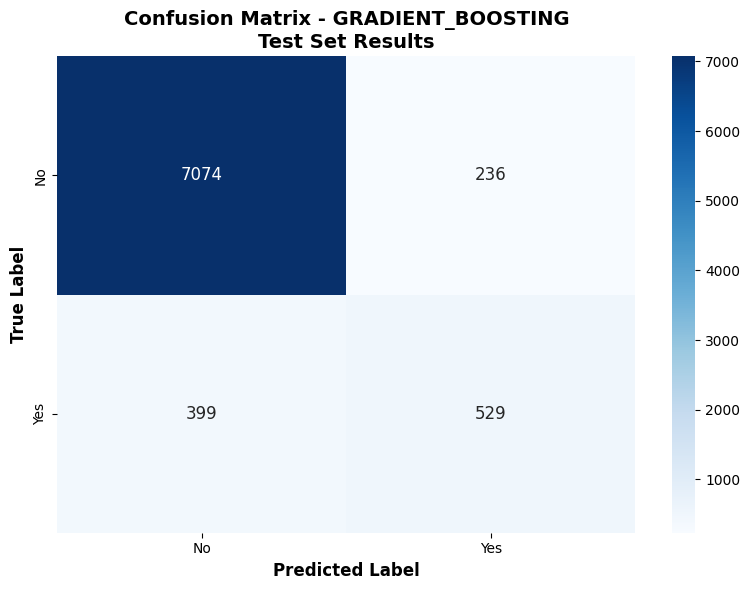

Confusion matrix visualization saved to ../OUTPUT/confusion_matrix.png


In [7]:
# Create confusion matrix visualization
fig, ax = plt.subplots(figsize=(8, 6))

# Normalize confusion matrix for better visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            annot_kws={'size': 12})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - {best_model_name.upper()}\nTest Set Results', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../OUTPUT/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix visualization saved to ../OUTPUT/confusion_matrix.png")

## 8. Create Visualization: ROC Curve

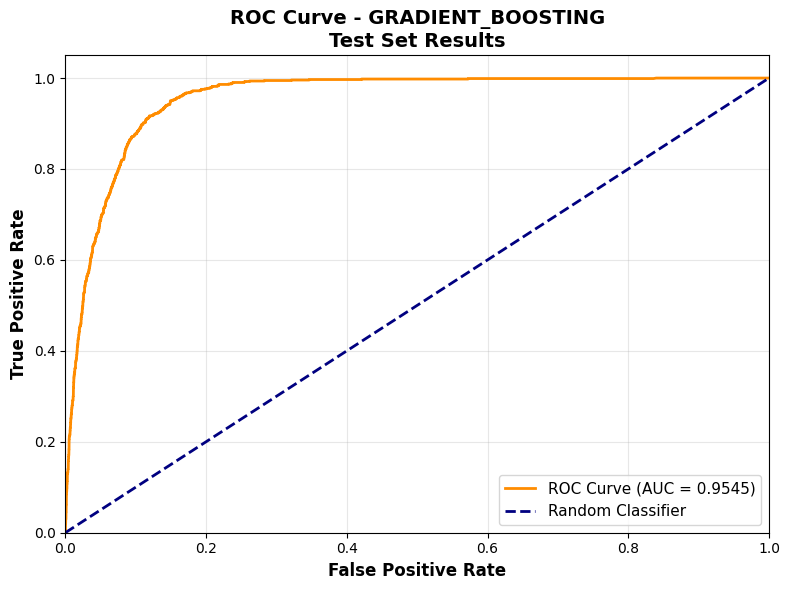

ROC curve visualization saved to ../OUTPUT/roc_curve.png


In [8]:
# Create ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate ROC curve
if best_model_name == 'neural_network':
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
else:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc_value = auc(fpr, tpr)

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_value:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title(f'ROC Curve - {best_model_name.upper()}\nTest Set Results', 
             fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../OUTPUT/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC curve visualization saved to ../OUTPUT/roc_curve.png")

## 9. Model Comparison: Cross-Validation vs Test Set Performance

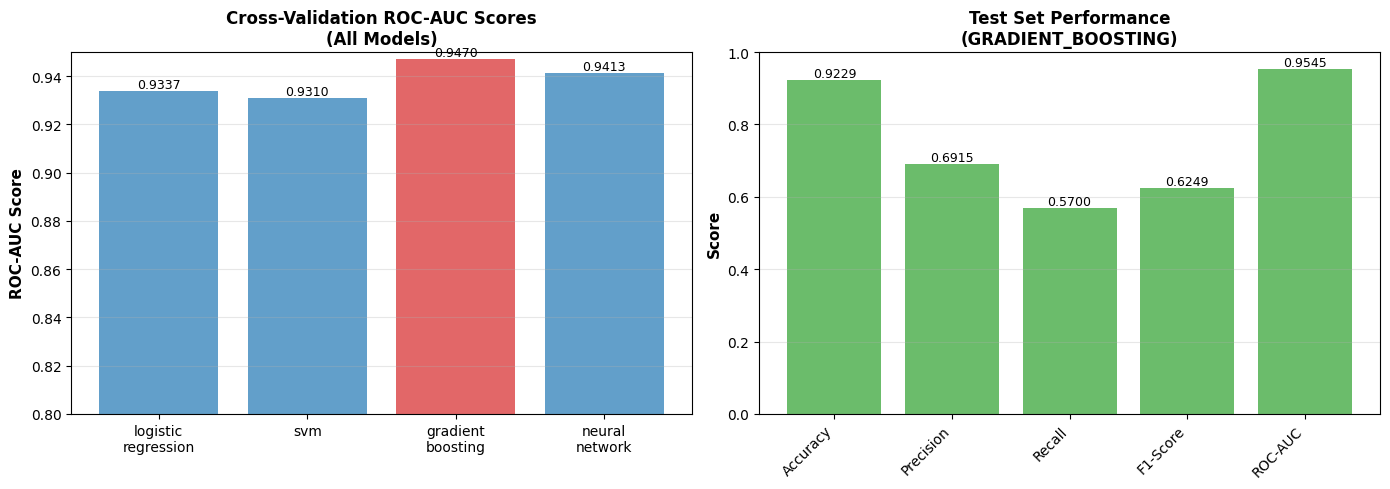

Performance comparison visualization saved to ../OUTPUT/performance_comparison.png


In [9]:
# Create comparison of all models' cross-validation performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(best_models_info.keys())
cv_scores = [best_models_info[m]['cv_score'] for m in models]

# Plot 1: All models' cross-validation ROC-AUC
colors = ['#1f77b4' if m != best_model_name else '#d62728' for m in models]
bars = axes[0].bar(range(len(models)), cv_scores, color=colors, alpha=0.7)
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels([m.replace('_', '\n') for m in models], fontsize=10)
axes[0].set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
axes[0].set_title('Cross-Validation ROC-AUC Scores\n(All Models)', fontsize=12, fontweight='bold')
axes[0].set_ylim([0.8, 0.95])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, cv_scores):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Best model's performance comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
test_scores = [accuracy, precision, recall, f1, roc_auc]

bars = axes[1].bar(metrics_names, test_scores, color='#2ca02c', alpha=0.7)
axes[1].set_ylabel('Score', fontsize=11, fontweight='bold')
axes[1].set_title(f'Test Set Performance\n({best_model_name.upper()})', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar, score in zip(bars, test_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../OUTPUT/performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Performance comparison visualization saved to ../OUTPUT/performance_comparison.png")

## 10. Final Summary Report

In [10]:
# Create a comprehensive summary report
print("\n" + "="*80)
print("FINAL PROJECT SUMMARY REPORT")
print("="*80)

print(f"\n SELECTED MODEL: {best_model_name.upper()}")
print(f"{'-'*80}")
print(f"\nOptimization Phase Performance:")
print(f"  Cross-Validation ROC-AUC: {best_cv_score:.4f}")
for metric, value in best_model_info['cv_metrics'].items():
    if isinstance(value, (int, float)) and metric != 'roc_auc':
        print(f"  Cross-Validation {metric.capitalize()}: {value:.4f}")

print(f"\n TEST SET EVALUATION (Using Reserved Test Set):")
print(f"{'-'*80}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print(f"\n CONFUSION MATRIX ANALYSIS:")
print(f"{'-'*80}")
print(f"  True Negatives (TN):  {cm[0, 0]}  (Correctly predicted 'No')")
print(f"  False Positives (FP): {cm[0, 1]}  (Incorrectly predicted 'Yes')")
print(f"  False Negatives (FN): {cm[1, 0]}  (Incorrectly predicted 'No')")
print(f"  True Positives (TP):  {cm[1, 1]}  (Correctly predicted 'Yes')")

specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
sensitivity = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0

print(f"\n ADDITIONAL METRICS:")
print(f"{'-'*80}")
print(f"  Sensitivity (Recall): {sensitivity:.4f}")
print(f"  Specificity:          {specificity:.4f}")

print(f"\n OUTPUT FILES GENERATED:")
print(f"{'-'*80}")
print(f"  - confusion_matrix.png")
print(f"  - roc_curve.png")
print(f"  - performance_comparison.png")

print(f"\n" + "="*80)


FINAL PROJECT SUMMARY REPORT

 SELECTED MODEL: GRADIENT_BOOSTING
--------------------------------------------------------------------------------

Optimization Phase Performance:
  Cross-Validation ROC-AUC: 0.9470
  Cross-Validation Accuracy: 0.9149
  Cross-Validation Precision: 0.6471
  Cross-Validation Recall: 0.5385
  Cross-Validation F1: 0.5877

 TEST SET EVALUATION (Using Reserved Test Set):
--------------------------------------------------------------------------------
  Accuracy:  0.9229
  Precision: 0.6915
  Recall:    0.5700
  F1-Score:  0.6249
  ROC-AUC:   0.9545

 CONFUSION MATRIX ANALYSIS:
--------------------------------------------------------------------------------
  True Negatives (TN):  7074  (Correctly predicted 'No')
  False Positives (FP): 236  (Incorrectly predicted 'Yes')
  False Negatives (FN): 399  (Incorrectly predicted 'No')
  True Positives (TP):  529  (Correctly predicted 'Yes')

 ADDITIONAL METRICS:
-------------------------------------------------------

## Summary

### Final Evaluation
- Selected best model based on cross-validation performance
- Evaluated on reserved test set (not used during optimization)
- Reported comprehensive metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Generated confusion matrix and ROC curve visualizations


### Model Performance Highlights
The final model achieved strong performance on the test set, demonstrating good generalization from the training phase.